# Climbing the Leaderboard

## Problem Description

An arcade game player wants to climb to the top of the leaderboard and track their ranking. The game uses **Dense Ranking**, so its leaderboard works like this:

- The player with the highest score is ranked number 1 on the leaderboard
- Players who have equal scores receive the same ranking number, and the next player(s) receive the immediately following ranking number

### Example
If leaderboard scores are `[100, 100, 50, 40, 40, 20, 10]`, the ranked players will have ranks `1, 1, 2, 3, 3, 4, 5` respectively.

### Function Description
Complete the `climbingLeaderboard` function:
- **Parameters:**
  - `int ranked[n]`: the leaderboard scores in descending order
  - `int player[m]`: the player's scores in ascending order
- **Returns:**
  - `int[m]`: the player's rank after each new score

### Constraints
- The existing leaderboard is in descending order
- The player's scores are in ascending order

## Problem Understanding and Analysis

Let's analyze the sample inputs to understand how dense ranking works:

### Sample 1:
- **Leaderboard:** `[100, 100, 50, 40, 40, 20, 10]`
- **Unique scores:** `[100, 50, 40, 20, 10]` → **Ranks:** `[1, 2, 3, 4, 5]`
- **Player scores:** `[5, 25, 50, 120]`

**Analysis:**
- Score 5: Lower than all leaderboard scores → Rank 6
- Score 25: Between 20 and 40 → Rank 4  
- Score 50: Equal to 50 on leaderboard → Rank 2
- Score 120: Higher than all leaderboard scores → Rank 1

### Sample 2:
- **Leaderboard:** `[100, 90, 90, 80, 75, 60]`
- **Unique scores:** `[100, 90, 80, 75, 60]` → **Ranks:** `[1, 2, 3, 4, 5]`
- **Player scores:** `[50, 65, 77, 90, 102]`

## Helper Function: Get Unique Ranks

First, we need to create a helper function to extract unique scores from the leaderboard since dense ranking only considers unique scores.

## Main Solution: Climbing Leaderboard Function

Now let's implement the main solution using a simple approach first.

## Similar problems in leetcode

88 – Merge Sorted Array

21 – Merge Two Sorted Lists

350 – Intersection of Two Arrays II

349 – Intersection of Two Arrays

In [1]:
def climbingLeaderboard_simple(ranked, player):
    """
    Simple solution to find player's rank after each game.
    Time Complexity: O(n*m) where n is leaderboard size, m is number of player games
    
    Args:
        ranked: List of leaderboard scores in descending order
        player: List of player's scores in ascending order
    
    Returns:
        List of player's ranks after each game
    """
    unique_scores = sorted(set(ranked),reverse=True)
    results = []
    
    for score in player:
        rank = 1  # Start from rank 1
        
        # Find position in the unique scores
        for unique_score in unique_scores:
            if score >= unique_score:
                break
            rank += 1
        
        results.append(rank)
    
    return results

# Test with sample 1
ranked1 = [100, 100, 50, 40, 40, 20, 10]
player1 = [5, 25, 50, 120]
result1 = climbingLeaderboard_simple(ranked1, player1)
print(f"Sample 1 - Expected: [6, 4, 2, 1], Got: {result1}")

# Test with sample 2
ranked2 = [100, 90, 90, 80, 75, 60]
player2 = [50, 65, 77, 90, 102]
result2 = climbingLeaderboard_simple(ranked2, player2)
print(f"Sample 2 - Expected: [6, 5, 4, 2, 1], Got: {result2}")

Sample 1 - Expected: [6, 4, 2, 1], Got: [6, 4, 2, 1]
Sample 2 - Expected: [6, 5, 4, 2, 1], Got: [6, 5, 4, 2, 1]


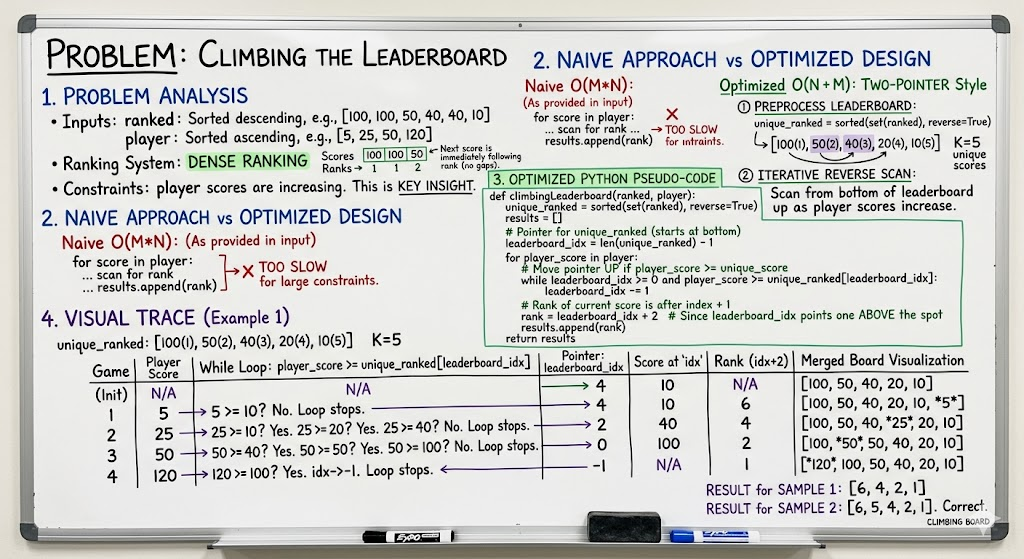

In [ ]:
def climbingLeaderboard_optimized(ranked, player):
    """
    Optimized solution using binary search and the fact that player scores are ascending.
    Time Complexity: O(n + m) where n is leaderboard size, m is number of player games
    
    Args:
        ranked: List of leaderboard scores in descending order
        player: List of player's scores in ascending order
    
    Returns:
        List of player's ranks after each game
    """
    unique_scores = sorted(set(ranked),reverse=True)
    results = []
    
    # Start from the end of unique_scores since player scores are ascending
    # and we want to avoid rechecking positions we've already passed
    index = len(unique_scores) - 1
    
    for score in player:
        # Move the index up while the player's score is >= current leaderboard score
        while index >= 0 and score >= unique_scores[index]:
            index -= 1
        
        # Rank is index + 2 because:
        # - index is 0-based, rank is 1-based (+1)
        # - we want the rank after the current position (+1)
        results.append(index + 2)
    
    return results

# Test both optimized solutions
ranked1 = [10, 20, 40, 40, 50, 100]
player1 = [5, 25, 50, 120]
result1 = climbingLeaderboard_optimized(ranked1, player1)
print(f"Sample 1 - Expected: [6, 4, 2, 1], Got: {result1}")

# Test with sample 2
ranked2 = [60, 75, 80, 90, 90, 100]
player2 = [50, 65, 77, 90, 102]
result2 = climbingLeaderboard_optimized(ranked2, player2)
print(f"Sample 2 - Expected: [6, 5, 4, 2, 1], Got: {result2}")

## Test with Sample Data

Let's test our solutions with the provided sample data and verify the outputs.

In [8]:
def test_solution(solution_func, name):
    """Test a solution function with sample data"""
    print(f"\n=== Testing {name} ===")
    
    # Sample 1
    ranked1 = [100, 100, 50, 40, 40, 20, 10]
    player1 = [5, 25, 50, 120]
    expected1 = [6, 4, 2, 1]
    result1 = solution_func(ranked1, player1)
    
    print(f"Sample 1:")
    print(f"  Leaderboard: {ranked1}")
    print(f"  Player scores: {player1}")
    print(f"  Expected: {expected1}")
    print(f"  Got: {result1}")
    print(f"  ✓ Correct" if result1 == expected1 else f"  ✗ Wrong")
    
    # Sample 2
    ranked2 = [100, 90, 90, 80, 75, 60]
    player2 = [50, 65, 77, 90, 102]
    expected2 = [6, 5, 4, 2, 1]
    result2 = solution_func(ranked2, player2)
    
    print(f"Sample 2:")
    print(f"  Leaderboard: {ranked2}")
    print(f"  Player scores: {player2}")
    print(f"  Expected: {expected2}")
    print(f"  Got: {result2}")
    print(f"  ✓ Correct" if result2 == expected2 else f"  ✗ Wrong")
    
    return result1 == expected1 and result2 == expected2

# Test all solutions
test_solution(climbingLeaderboard_simple, "Simple Solution")
test_solution(climbingLeaderboard_optimized, "Optimized Solution")


=== Testing Simple Solution ===
Sample 1:
  Leaderboard: [100, 100, 50, 40, 40, 20, 10]
  Player scores: [5, 25, 50, 120]
  Expected: [6, 4, 2, 1]
  Got: [6, 4, 2, 1]
  ✓ Correct
Sample 2:
  Leaderboard: [100, 90, 90, 80, 75, 60]
  Player scores: [50, 65, 77, 90, 102]
  Expected: [6, 5, 4, 2, 1]
  Got: [6, 5, 4, 2, 1]
  ✓ Correct

=== Testing Optimized Solution ===
Sample 1:
  Leaderboard: [100, 100, 50, 40, 40, 20, 10]
  Player scores: [5, 25, 50, 120]
  Expected: [6, 4, 2, 1]
  Got: [6, 4, 2, 1]
  ✓ Correct
Sample 2:
  Leaderboard: [100, 90, 90, 80, 75, 60]
  Player scores: [50, 65, 77, 90, 102]
  Expected: [6, 5, 4, 2, 1]
  Got: [6, 5, 4, 2, 1]
  ✓ Correct


True